# Trades Universe Inspection Notebook v0.1

Este notebook existe para inspeccionar **todo el universo `trades` de `57f/full_clean_fast_same_schema`** con la granularidad institucional actual.

No sustituye los `.md` por familia. Los complementa con una capa poblacional ejecutable y mucho mas ambiciosa.


**Alcance exacto:** este notebook trabaja sobre el universo `lt1b` materializado en `57f/full_clean_fast_same_schema`, no sobre un universo all-cap sin ese corte.


## Como debe leerse este notebook

La regla correcta es separar siempre:

1. masa poblacional completa;
2. firmas globales del problema;
3. buckets o familias semanticas;
4. y casos file-level.

Este notebook responde sobre todo a las preguntas de los **tres primeros niveles**.

No responde, por si solo, a la causalidad exacta de cada file individual. Para eso siguen existiendo:

- `case_pack`
- `muestra_380`
- y los `.md` por familia.


## Bloques que vas a poder lanzar

Cada celda de codigo de este notebook ejecuta un bloque distinto del universo:

- `resumen`
- `mezcla_anual`
- `escala`
- `firmas_duras`
- `outside_daily`
- `outside_1m`
- `duplicacion`
- `odd_lot`
- `cobertura_1m`

La idea es que el inspector pueda ver tanto la imagen como la tabla, sin salir del notebook.


## Carga del modulo


In [1]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.inspection.trades.trades_universe_panel as trades_universe_panel
importlib.reload(trades_universe_panel)

from scripts.inspection.trades.trades_universe_panel import (
    compute_trades_universe_snapshot,
    render_trades_universe_assets,
    universe_overview_tables,
    display_trades_universe_section,
)


## Recalculo y export de activos

Usa esta celda cuando quieras forzar el recomputo completo del snapshot y de todos los graficos de universo.

Es la celda mas costosa, porque recorre todos los shards de `57f`.


In [2]:
snapshot = compute_trades_universe_snapshot(force=True)
assets = render_trades_universe_assets(force=False)
snapshot["policy_counts"], snapshot["review_rehabilitation"], assets


({'review': 4851211,
  'reference_scale_mismatch': 2418062,
  'review_microstructure': 2130781,
  'bad_data': 15869,
  'review_no_1m_reference': 8091,
  'review_1m_reference_alignment': 4992,
  'good': 106},
 {'review_total': 4851211, 'strict': 3327955, 'extended': 3505290},
 {'acceptance_distribution': 'C:\\TSIS_Data\\01_TSIS_backtest_SmallCaps\\01_foundations\\inspection_dossiers\\trades\\evidence_assets\\global_universe\\00_acceptance_distribution.png',
  'yearly_acceptance_mix': 'C:\\TSIS_Data\\01_TSIS_backtest_SmallCaps\\01_foundations\\inspection_dossiers\\trades\\evidence_assets\\global_universe\\01_yearly_acceptance_mix.png',
  'scale_bucket_mix_by_label': 'C:\\TSIS_Data\\01_TSIS_backtest_SmallCaps\\01_foundations\\inspection_dossiers\\trades\\evidence_assets\\global_universe\\02_scale_bucket_mix_by_label.png',
  'signature_mix_by_label': 'C:\\TSIS_Data\\01_TSIS_backtest_SmallCaps\\01_foundations\\inspection_dossiers\\trades\\evidence_assets\\global_universe\\03_signature_mix_b

## Resumen ejecutivo

Responde a:

- cuanta masa hay en cada `acceptance_label`;
- por que `good` no mide la masa util real;
- y cuanta parte de `review` ya es rehabilitable.


## Resumen del universo `trades`

Responde a: cuanta masa hay, como se reparte, y por que `good` no mide la masa util real del bloque.

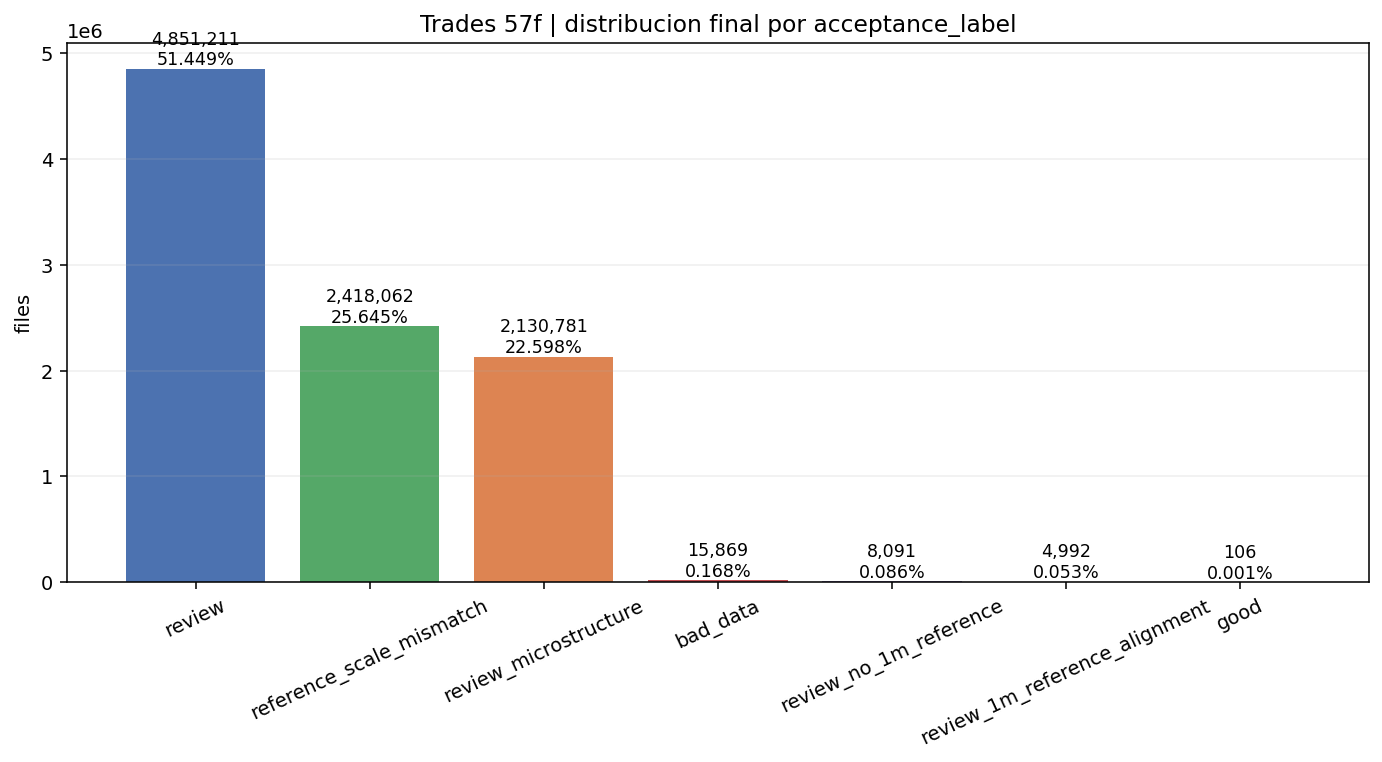

,acceptance_label,files
0,review,4851211
1,reference_scale_mismatch,2418062
2,review_microstructure,2130781
3,bad_data,15869
4,review_no_1m_reference,8091
5,review_1m_reference_alignment,4992
6,good,106


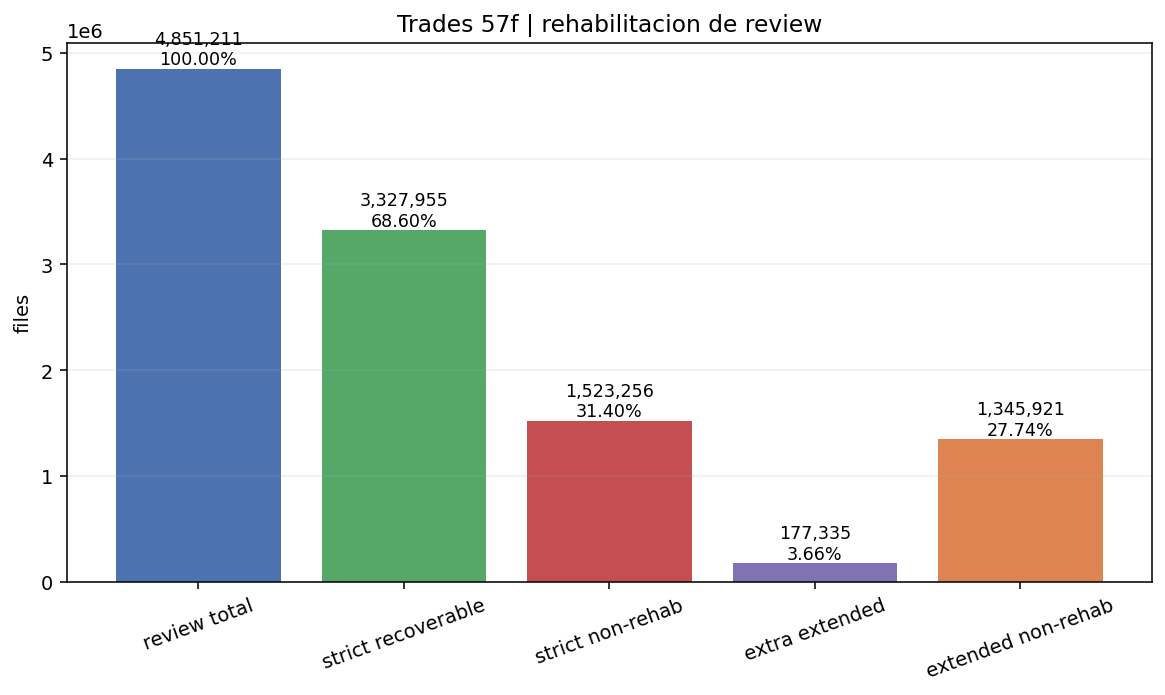

,review_total,strict,extended
0,4851211,3327955,3505290


In [3]:
display_trades_universe_section('resumen')


## Mezcla anual

Responde a:

- si el problema es transversal en el tiempo;
- o si determinadas familias se concentran en periodos concretos.


## Mezcla anual

Responde a: si las familias cambian por periodo y si el problema se concentra en anos concretos o atraviesa el universo entero.

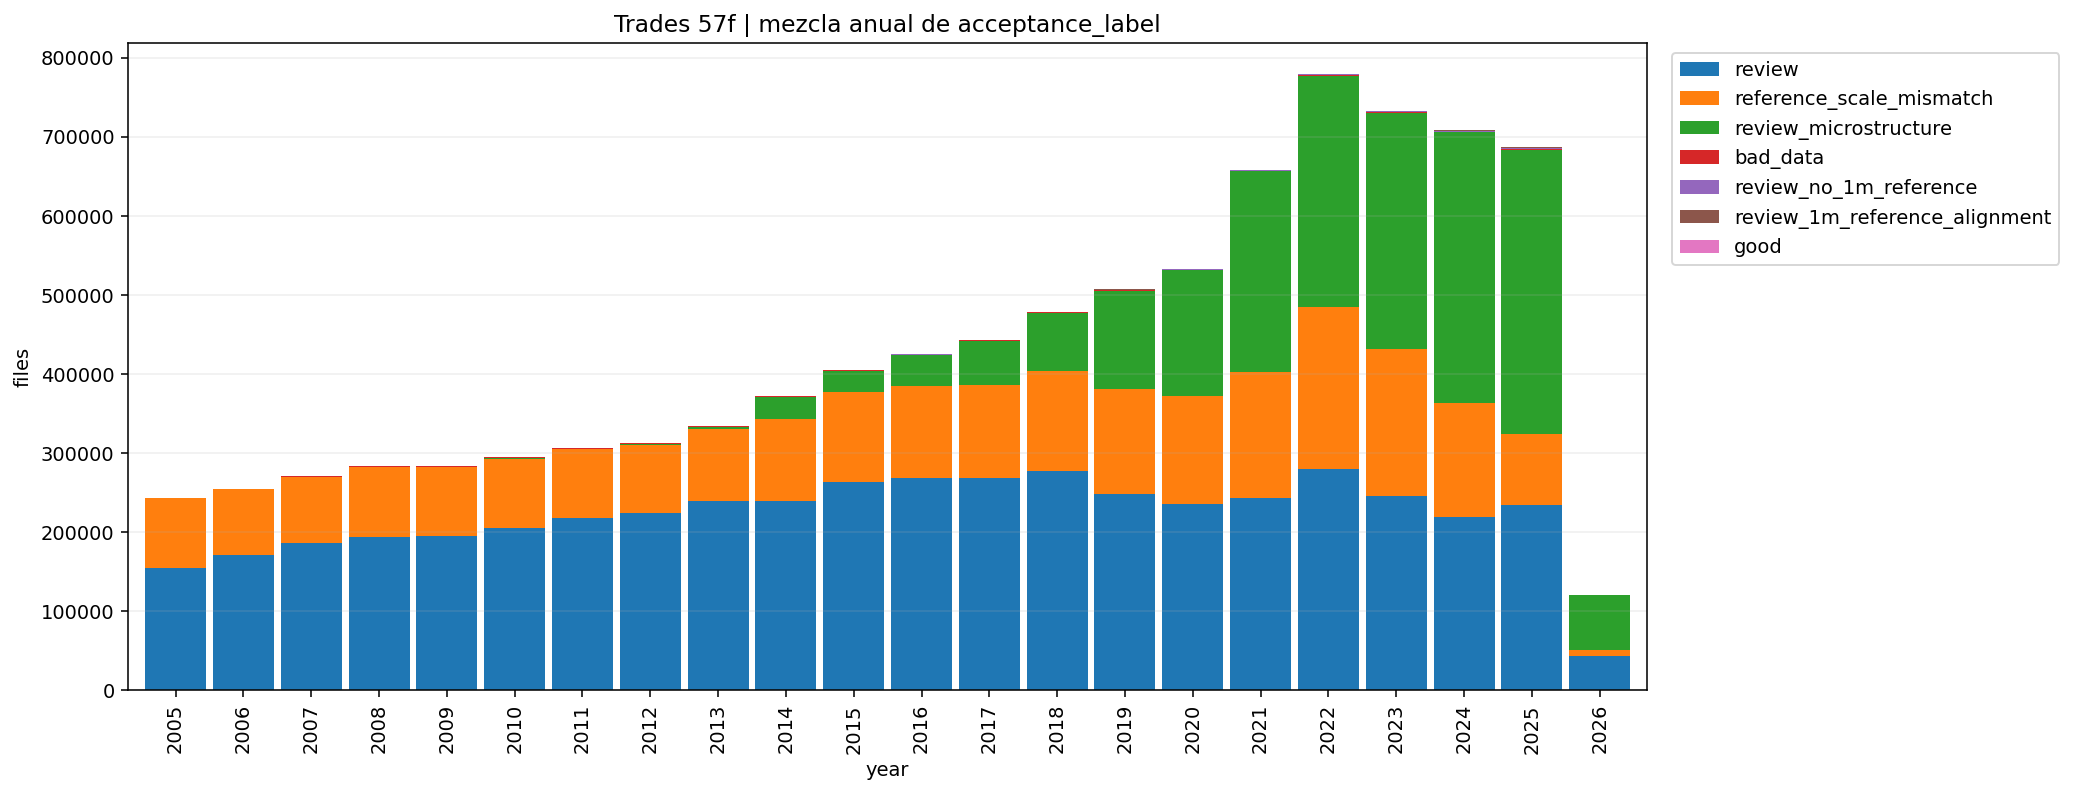

,year,review,reference_scale_mismatch,review_microstructure,bad_data,review_no_1m_reference,review_1m_reference_alignment,good
7,2012,224480,85970,775,747,26,65,5
8,2013,239301,90465,3551,793,103,85,1
9,2014,238839,103726,28481,868,103,179,0
10,2015,263035,114157,26702,781,237,151,1
11,2016,268398,116754,38379,880,269,241,3
12,2017,268514,116742,56110,933,350,533,2
13,2018,276836,126520,73249,1164,446,502,12
14,2019,247649,133624,123446,1246,684,388,18
15,2020,235674,136490,158796,685,421,328,12
16,2021,242489,160218,253377,624,671,375,1


In [4]:
display_trades_universe_section('mezcla_anual')


## Escala y comparabilidad

Responde a:

- donde domina el conflicto de escala;
- por que `reference_scale_mismatch` no debe confundirse con tape roto;
- y como cambia la firma de `scale_bucket_vw` por label.


## Escala y comparabilidad

Responde a: donde domina el conflicto de escala y por que `reference_scale_mismatch` no debe confundirse con tape roto.

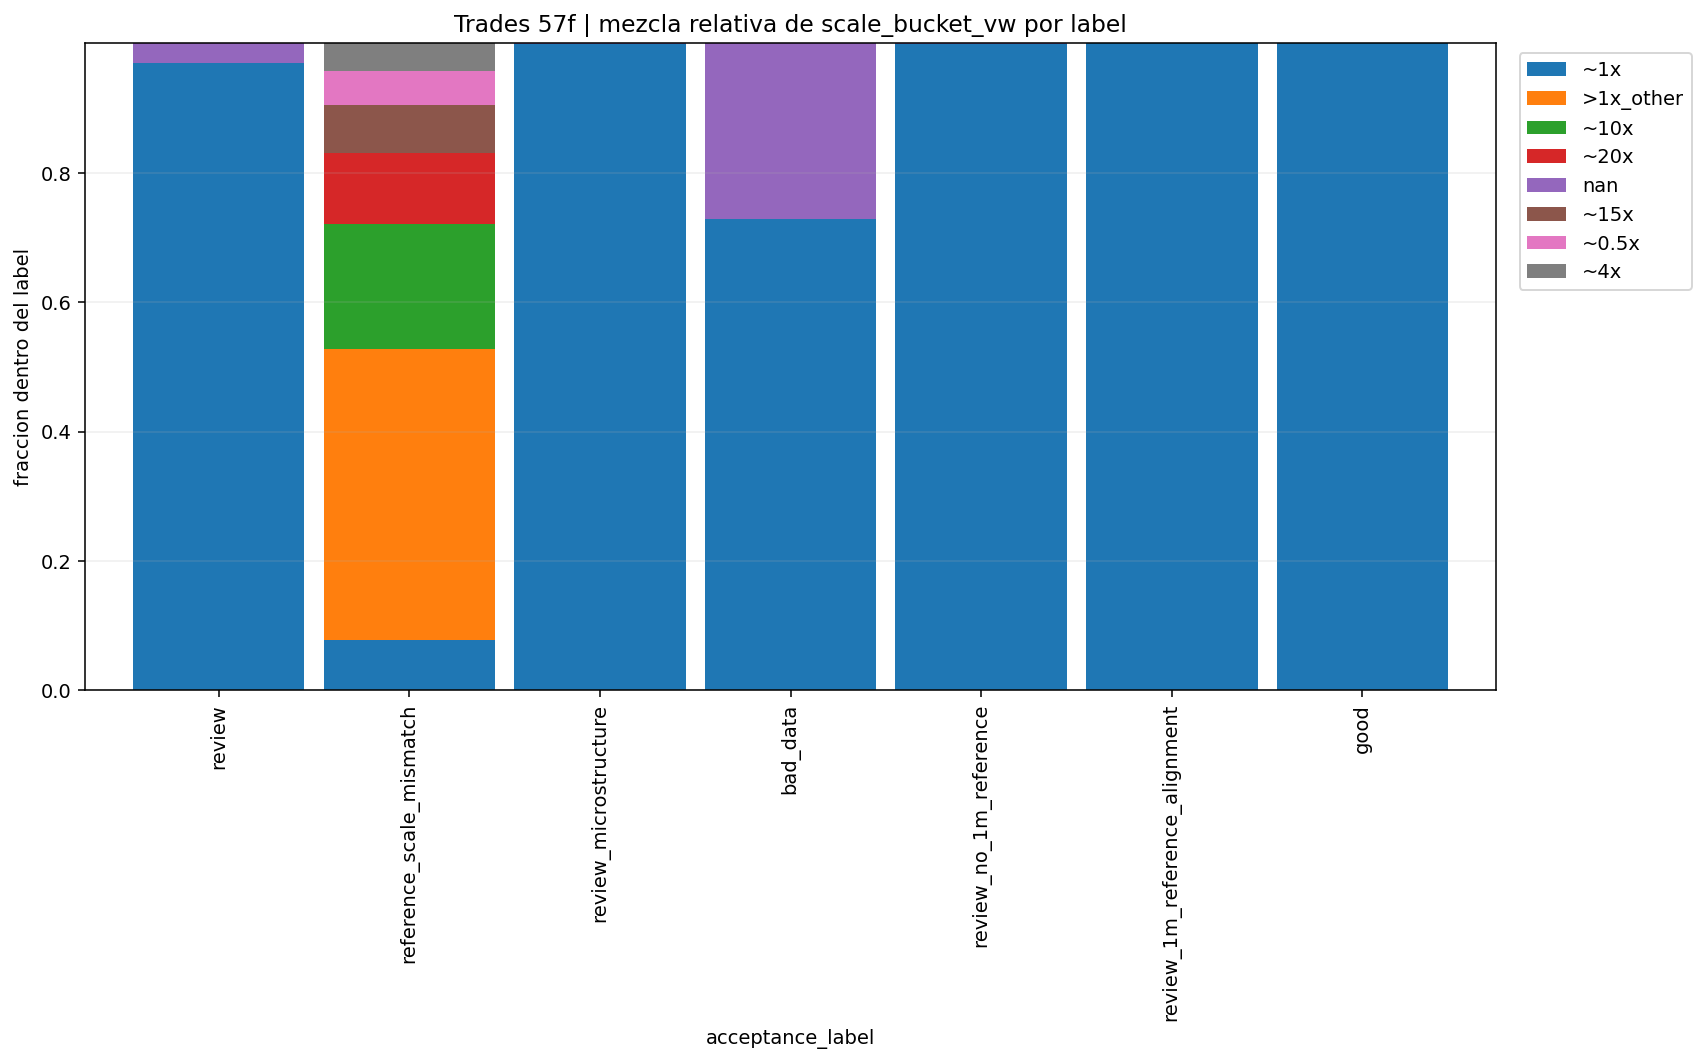

,<1x_other,>1x_other,nan,near_0.1x,near_0.25x,near_0.2x,near_0.3333x,near_0.5x,near_0.6667x,near_0.8x,...,~1x,~20x,~2x,~30000x,~300x,~3x,~4x,~5000x,~5x,~6x
acceptance_label,,,,,,,,,,,,,,,,,,,,,
review,63,99,145645,1,0,1,8,15,76,175,...,4689724,0,22,0,0,1,2,0,0,0
reference_scale_mismatch,21101,812171,0,6,1710,6,739,1433,6121,20790,...,140406,196902,21364,1299,18342,31713,76543,7088,70769,39841
review_microstructure,11,65,2650,1,0,0,2,4,15,62,...,2122910,0,13,0,0,1,0,0,0,0
bad_data,31,12,4247,0,1,2,3,3,4,5,...,11407,0,0,0,0,0,0,0,0,0
review_no_1m_reference,0,0,3,0,0,0,0,0,0,0,...,8088,0,0,0,0,0,0,0,0,0
review_1m_reference_alignment,0,0,0,0,0,0,0,0,0,0,...,4992,0,0,0,0,0,0,0,0,0
good,0,0,0,0,0,0,0,0,0,0,...,105,0,0,0,0,0,0,0,0,0


In [5]:
display_trades_universe_section('escala')


## Firmas duras

Responde a:

- que senales dominan cada familia;
- donde vive la cola de integridad estructural;
- y que parte del universo necesita paneles complementarios mas alla del precio.


## Firmas duras

Responde a: que senales concretas dominan cada label y donde vive la cola de integridad estructural.

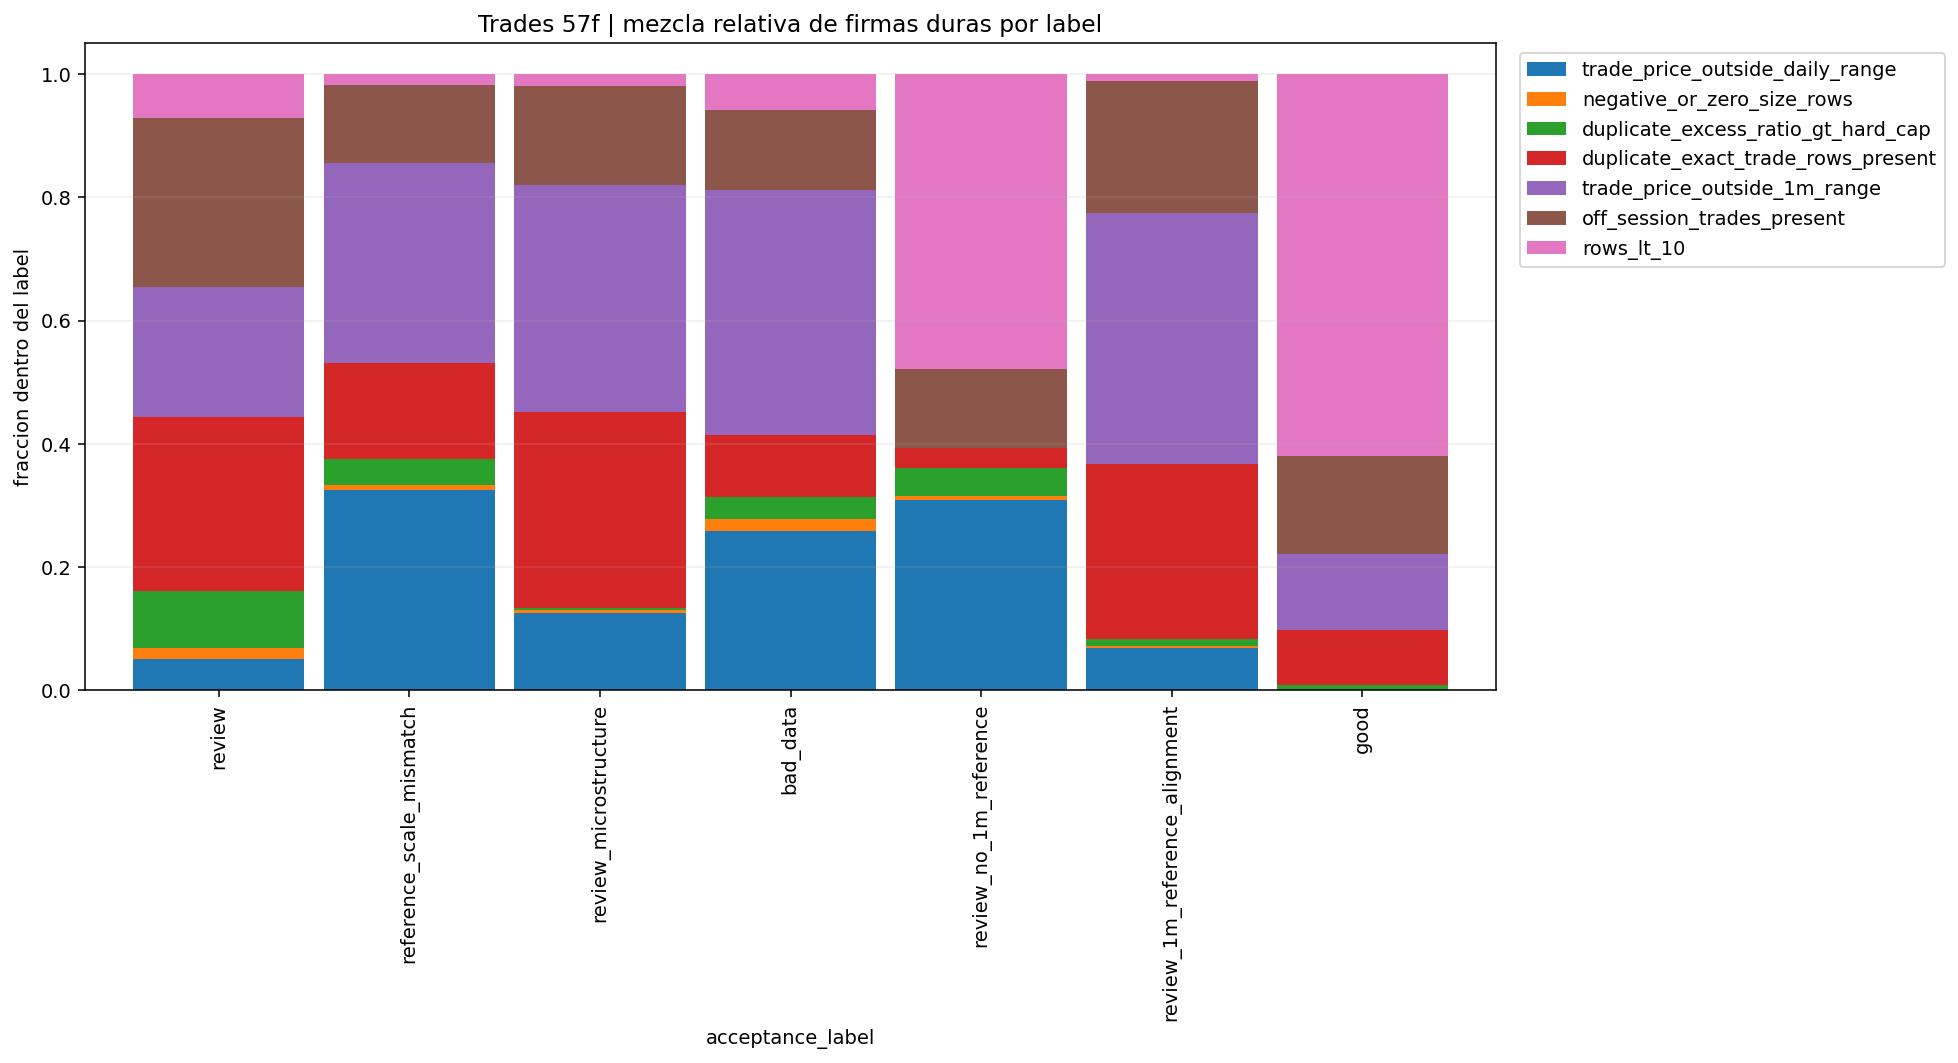

,duplicate_exact_trade_rows_present,duplicate_excess_ratio_gt_hard_cap,negative_or_zero_size_rows,off_session_trades_present,rows_lt_10,trade_price_outside_1m_range,trade_price_outside_daily_range
acceptance_label,,,,,,,
review,1631431,538266,98679,1580549,413174,1225325,293000
reference_scale_mismatch,991681,269614,45131,800326,114359,2050814,2064265
review_microstructure,1456022,16954,19999,730390,89277,1685448,576774
bad_data,3734,1329,695,4789,2168,14743,9606
review_no_1m_reference,370,527,79,1458,5482,0,3525
review_1m_reference_alignment,2433,89,34,1837,91,3478,583
good,10,1,0,18,70,14,0


In [6]:
display_trades_universe_section('firmas_duras')


## Severidad frente a `daily`

Responde a:

- como de agresiva es la ruptura contra el arbitro diario dentro de cada label;
- y donde el conflicto es local frente a donde ya es practicamente total.


## Severidad frente a `daily`

Responde a: como de agresivo es el conflicto contra el arbitro diario dentro de cada label.

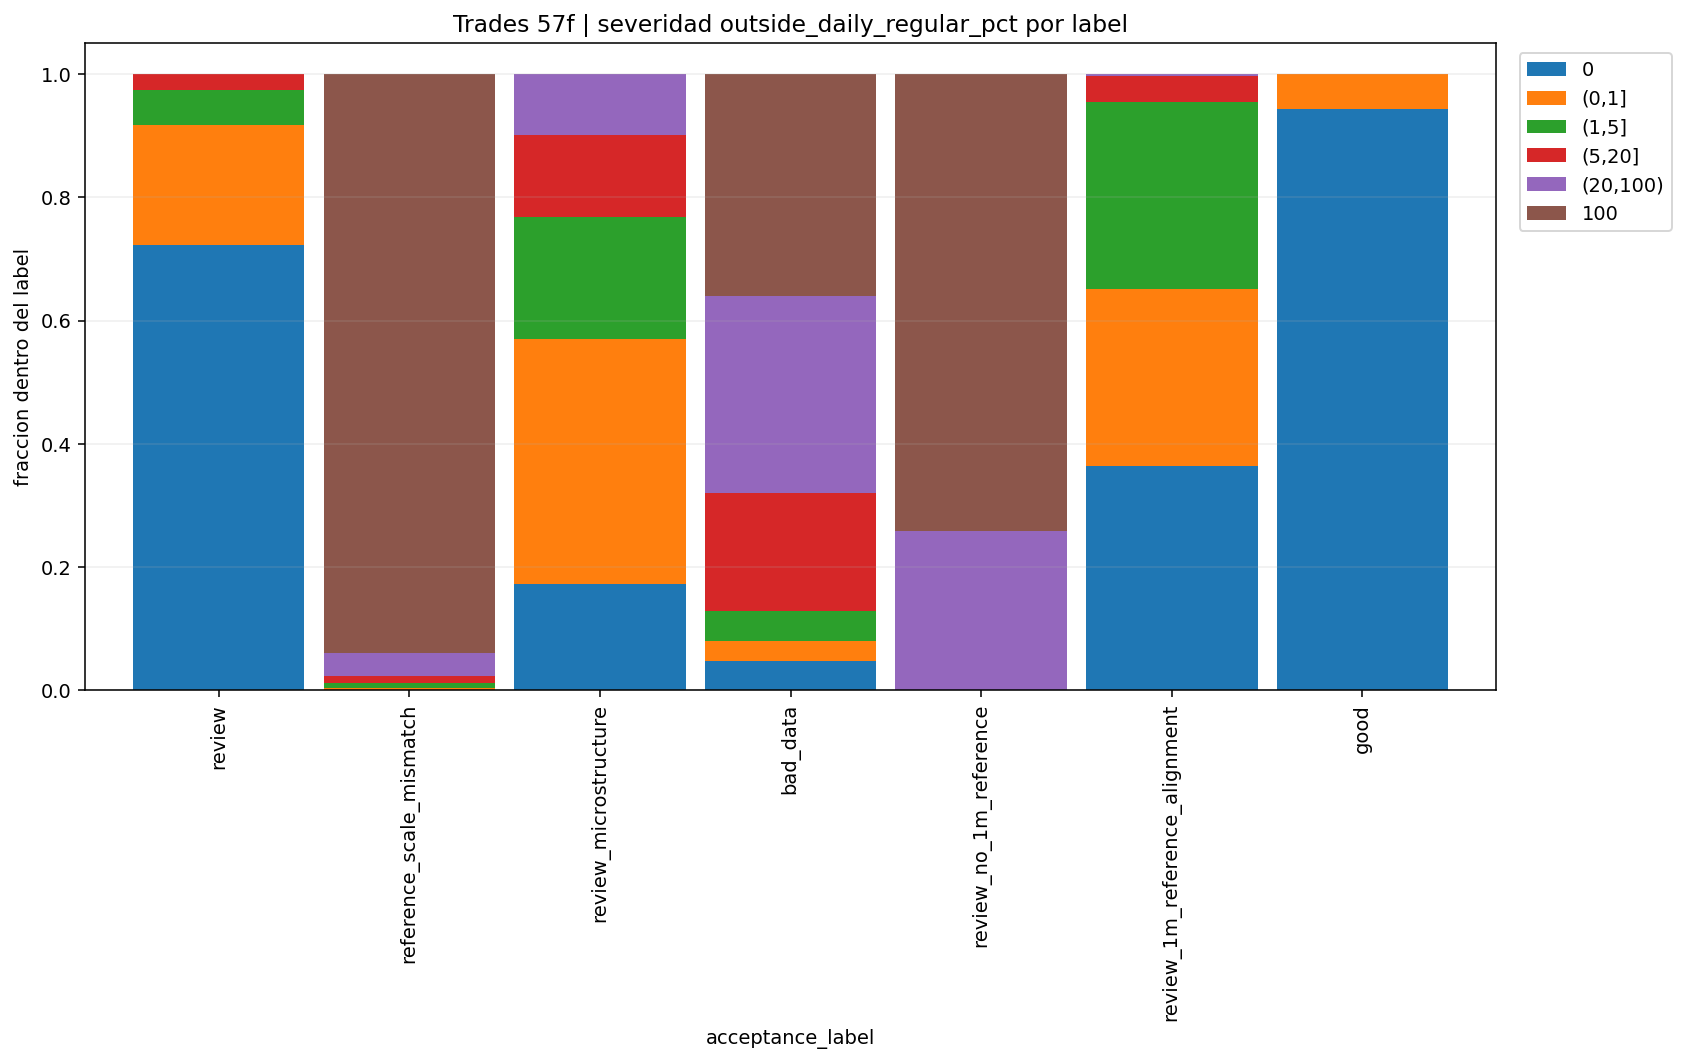

,"(0,1]","(1,5]","(20,100)","(5,20]",0,100
acceptance_label,,,,,,
review,947327,276540,126,123540,3503678,0
reference_scale_mismatch,10209,19403,91231,24116,521,2272582
review_microstructure,847820,420965,210400,282574,368846,176
bad_data,501,790,5091,3021,759,5707
review_no_1m_reference,0,0,2098,0,0,5993
review_1m_reference_alignment,1433,1512,14,215,1818,0
good,6,0,0,0,100,0


In [7]:
display_trades_universe_section('outside_daily')


## Severidad frente a `1m`

Responde a:

- como de agresiva es la ruptura contra el arbitro intradia fino;
- y por que `1m` cambia la verdad del caso en familias como `review_1m_reference_alignment`.


## Severidad frente a `1m`

Responde a: como de agresivo es el conflicto contra el arbitro intradia fino dentro de cada label.

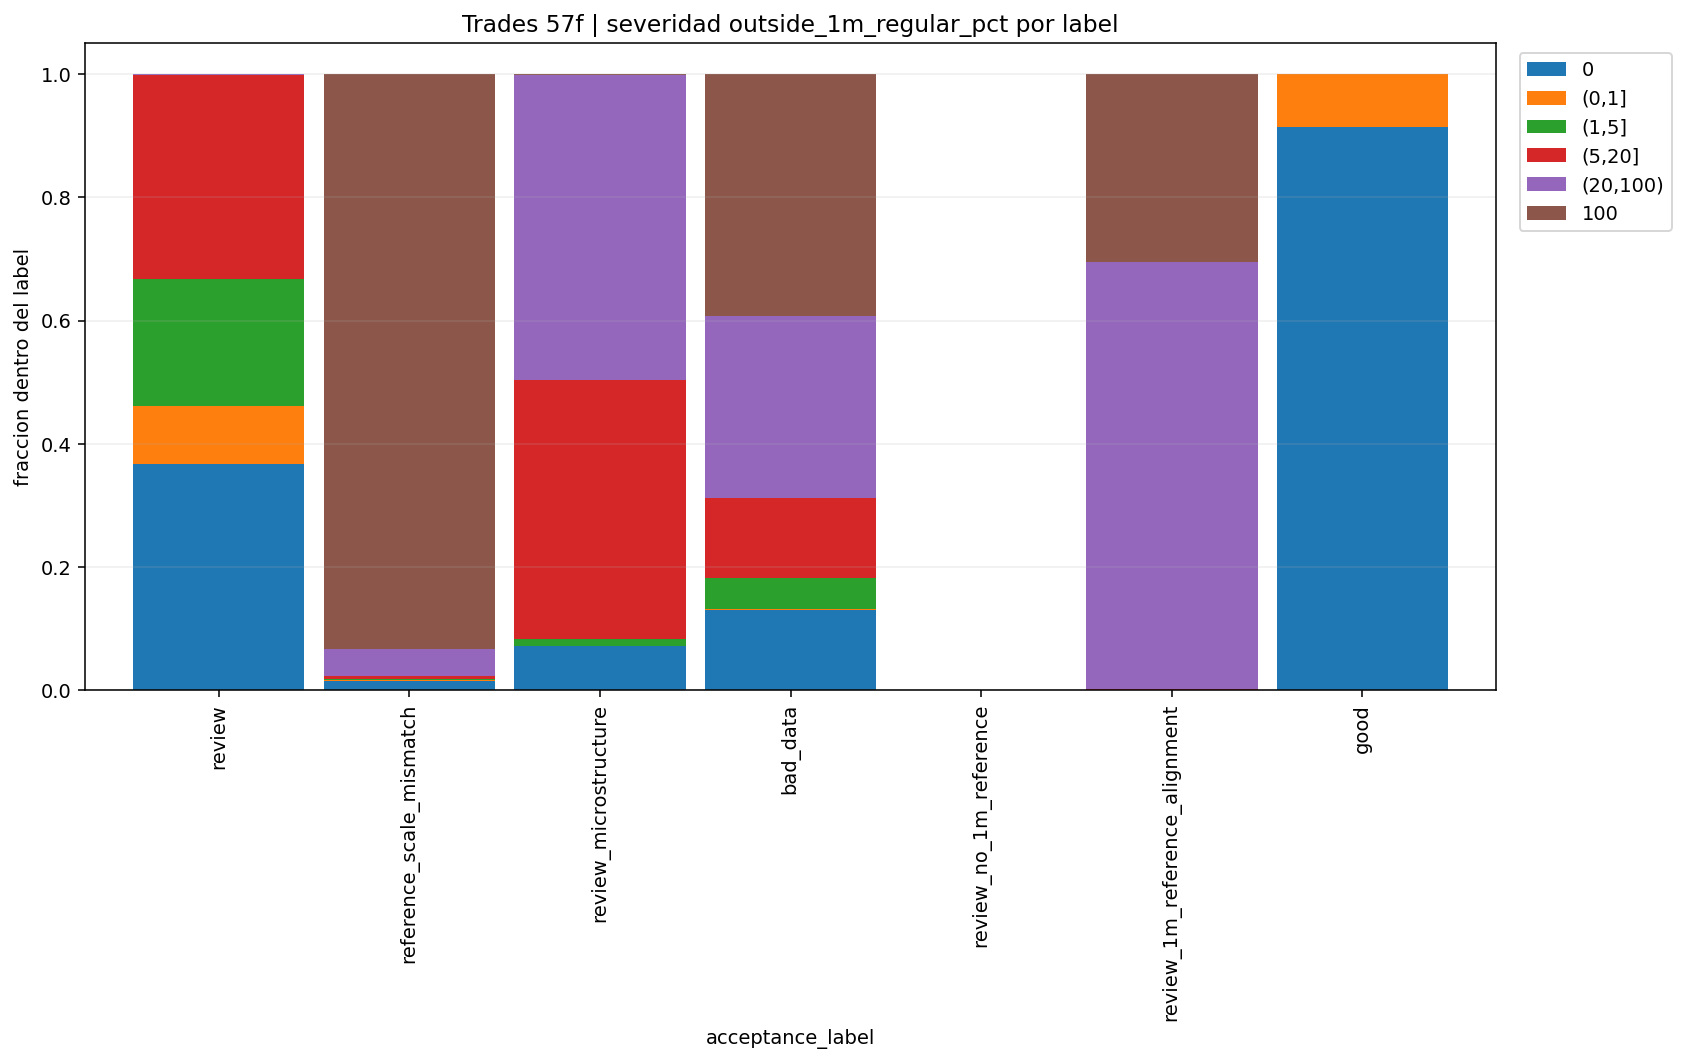

,"(0,1]","(1,5]","(20,100)","(5,20]",0,100
acceptance_label,,,,,,
review,354138,775152,2094,1249800,1380069,0
reference_scale_mismatch,3555,2767,86482,9480,28310,1827528
review_microstructure,548,17725,861688,729600,125014,994
bad_data,17,639,3690,1619,1625,4910
review_no_1m_reference,0,0,0,0,0,0
review_1m_reference_alignment,0,0,3468,6,0,1518
good,9,0,0,0,97,0


In [8]:
display_trades_universe_section('outside_1m')


## Duplicacion

Responde a:

- cuanto del conflicto vive en duplicacion del tape;
- y en que labels la integridad estructural pesa mas que la geometria del precio.


## Duplicacion

Responde a: cuanto de la lectura vive en bursts y filas repetidas, no solo en precio.

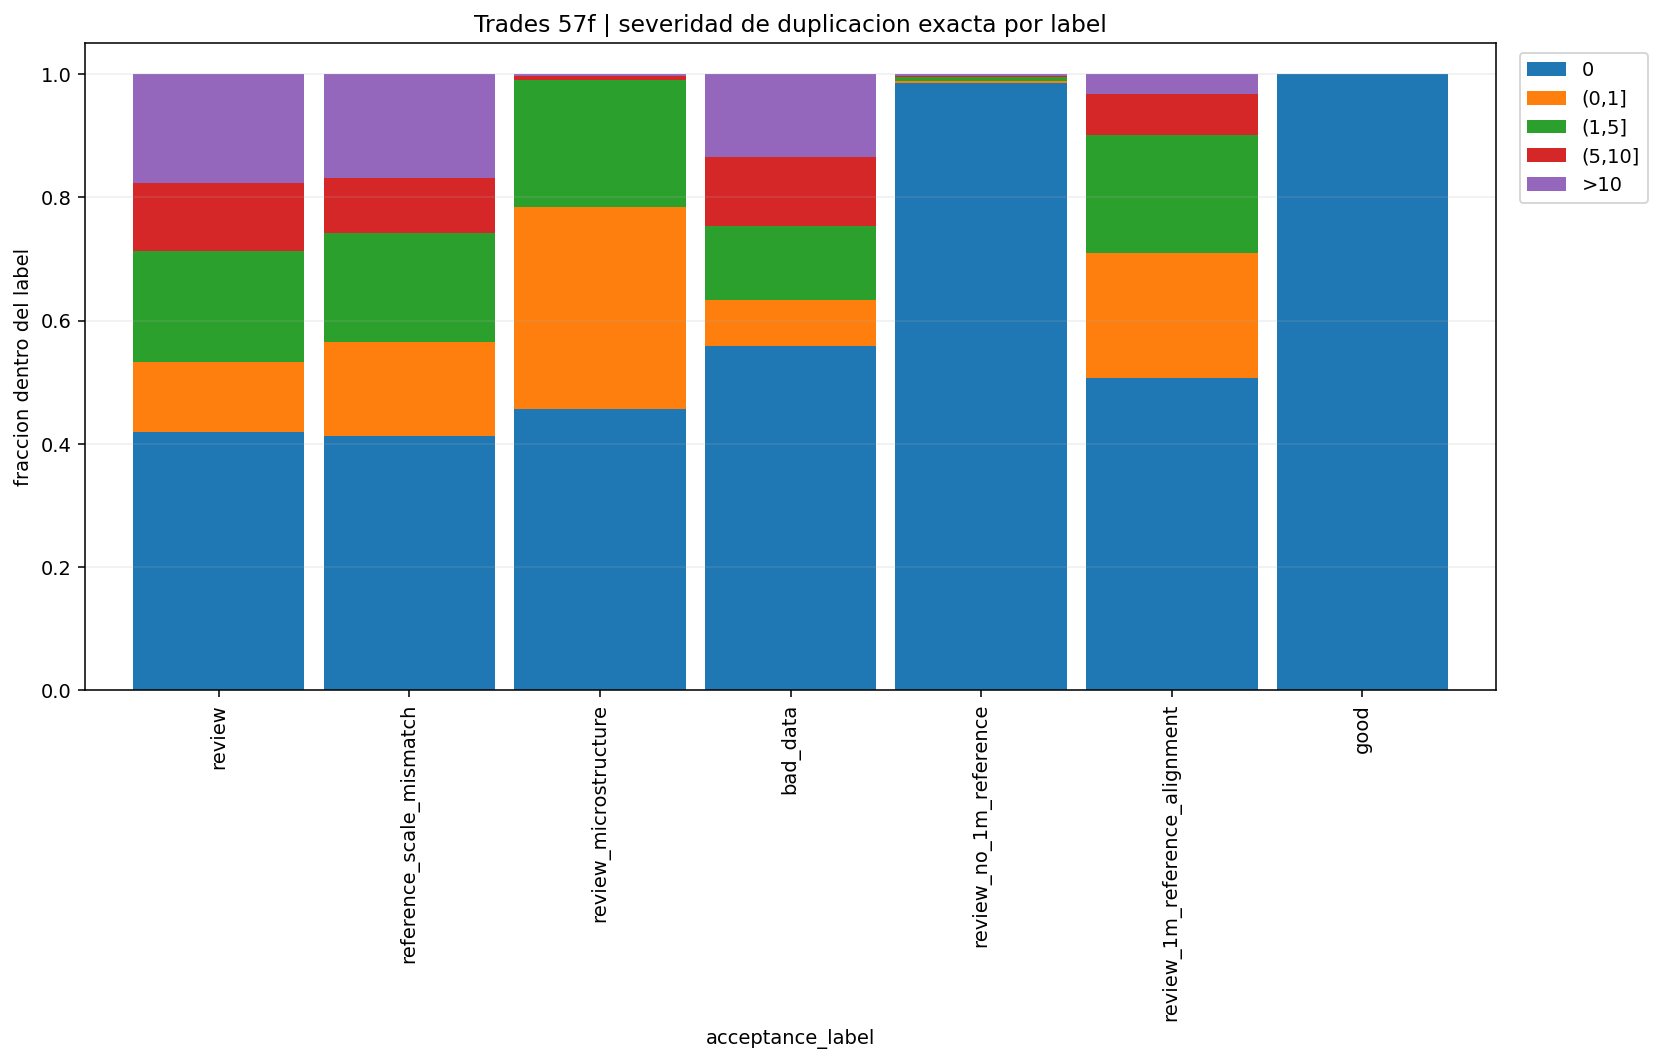

,"(0,1]","(1,5]","(5,10]",0,>10
acceptance_label,,,,,
review,550395,870077,538598,2035071,857070
reference_scale_mismatch,368295,426520,214731,999884,408632
review_microstructure,698840,438683,14342,973459,5457
bad_data,1178,1908,1780,8868,2135
review_no_1m_reference,19,55,17,7978,22
review_1m_reference_alignment,1007,963,326,2533,163
good,0,0,0,106,0


In [9]:
display_trades_universe_section('duplicacion')


## Odd-lots y textura microestructural

Responde a:

- hasta que punto la composicion de odd-lots explica la masa `review_microstructure`;
- y donde la textura del tape importa mas que la comparacion gruesa con arbitros.


## Odd-lots

Responde a: hasta que punto la textura microestructural explica parte del conflicto.

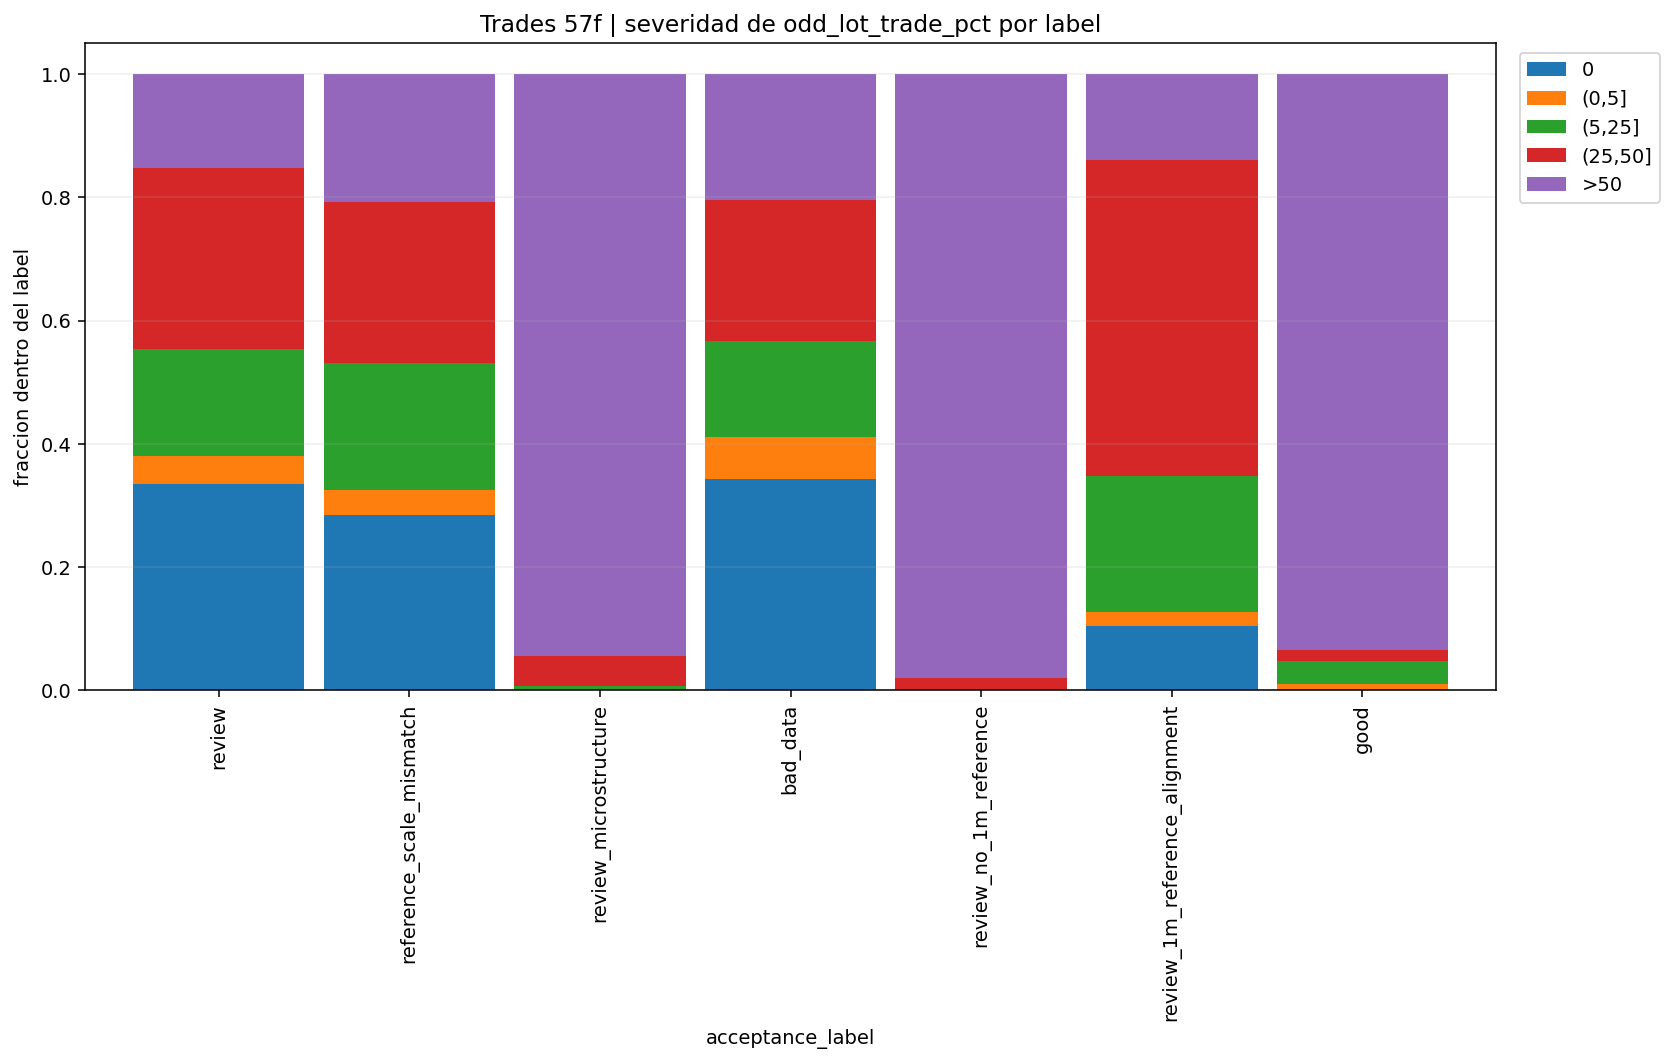

,"(0,5]","(25,50]","(5,25]",0,>50
acceptance_label,,,,,
review,222397,1422591,840491,1624753,740979
reference_scale_mismatch,97633,632034,499054,688333,501008
review_microstructure,0,105151,14502,0,2011128
bad_data,1075,3636,2469,5453,3236
review_no_1m_reference,0,149,0,9,7933
review_1m_reference_alignment,119,2559,1100,519,695
good,1,2,4,0,99


In [10]:
display_trades_universe_section('odd_lot')


## Cobertura del arbitro `1m`

Responde a:

- donde el problema esta condicionado por falta de arbitro fino;
- y por que `review_no_1m_reference` no debe leerse como corrupcion probada.


## Cobertura del arbitro `1m`

Responde a: donde el problema esta condicionado por falta de arbitro fino y donde no.

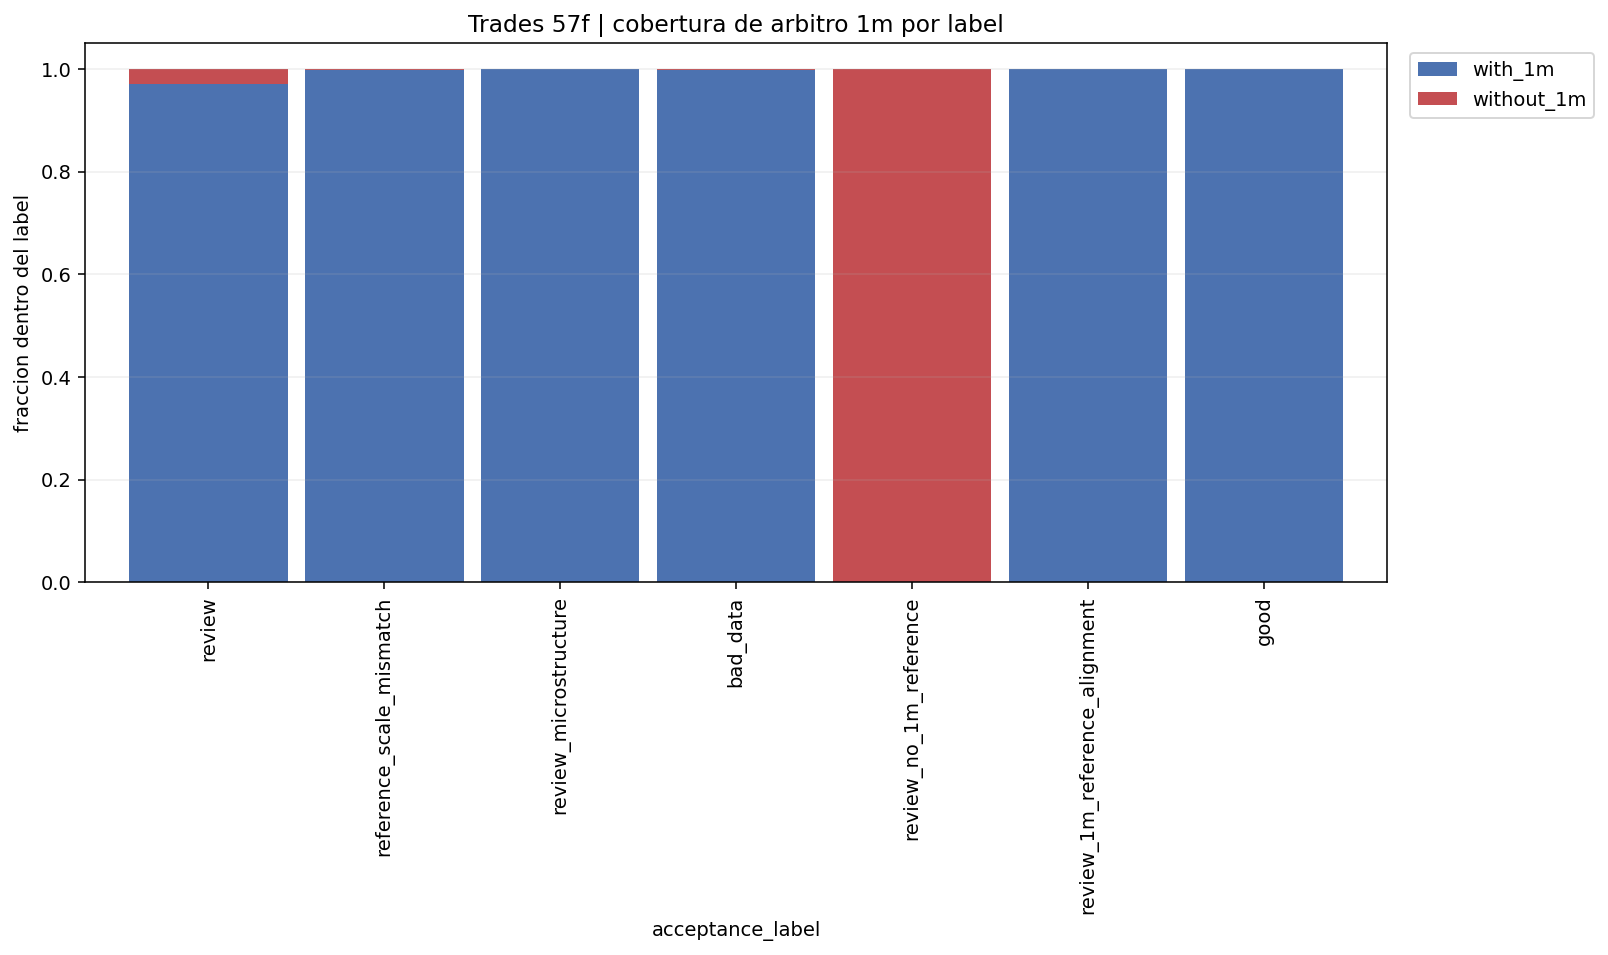

,with_1m,without_1m
review,4708882,142329
reference_scale_mismatch,2413502,4560
review_microstructure,2128361,2420
bad_data,15833,36
review_no_1m_reference,0,8091
review_1m_reference_alignment,4992,0
good,106,0


In [11]:
display_trades_universe_section('cobertura_1m')


## Acceso directo a tablas

Si necesitas trabajar con tablas crudas dentro del notebook, esta celda te deja el diccionario listo.


In [12]:
tables = universe_overview_tables(force=False)
list(tables.keys())


['policy',
 'yearly',
 'scale',
 'signatures',
 'outside_daily',
 'outside_1m',
 'duplicate',
 'odd_lot',
 'has_1m',
 'review_rehabilitation',
 'bad_data_subfamilies',
 'review_microstructure_textures',
 'reference_scale_mismatch_buckets',
 'review_rehab_categories']

## `bad_data` por subfamilia visual

Responde a:

- cuanto de `bad_data` se ve por colapso de escala/rango;
- cuanto vive en integridad estructural;
- y donde el panel de precio deja de bastar por si solo.


## `bad_data` por subfamilia visual

Responde a: que parte de `bad_data` se ve por colapso de escala/rango y que parte exige paneles de integridad estructural.

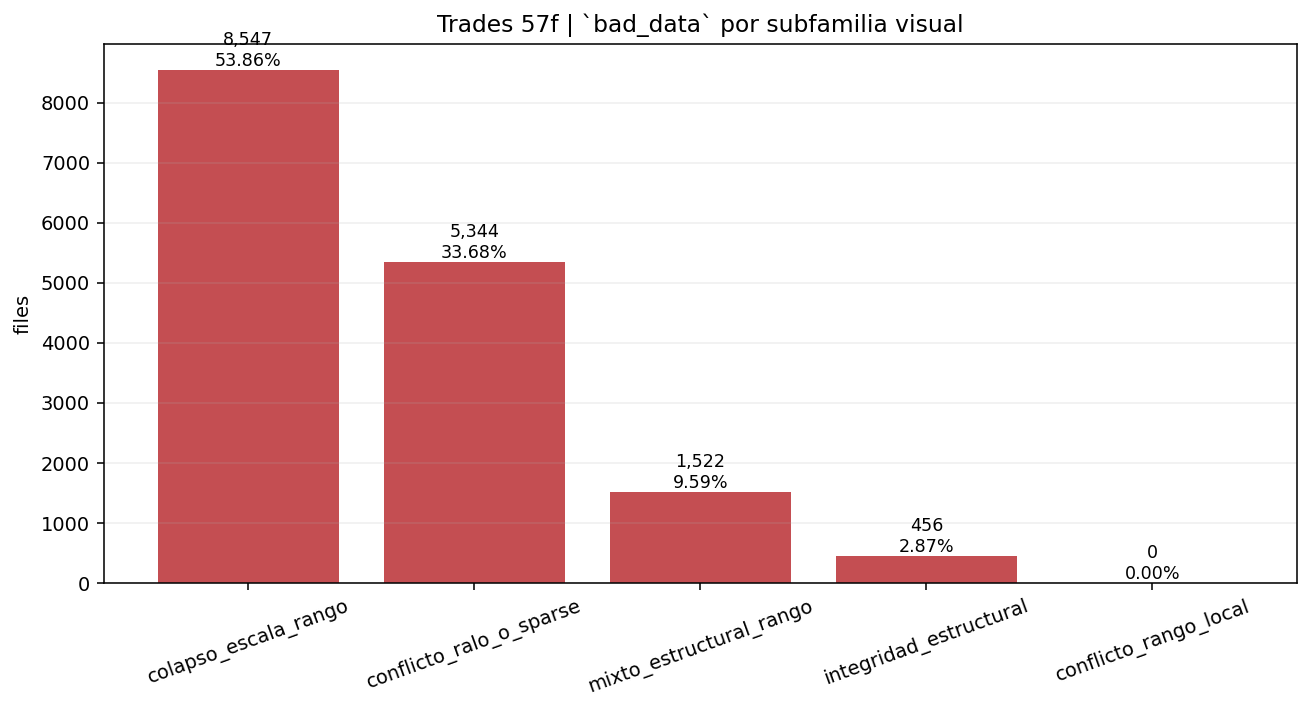

,colapso_escala_rango,integridad_estructural,mixto_estructural_rango,conflicto_ralo_o_sparse,conflicto_rango_local
0,8547,456,1522,5344,0


In [13]:
display_trades_universe_section('bad_data_subfamilias')


## `review_microstructure` por textura dominante

Responde a:

- si el bucket esta dominado por odd-lots;
- si la cola relevante vive en duplicacion o sparsity;
- y donde el conflicto fino contra `1m` pesa de verdad.


## `review_microstructure` por textura dominante

Responde a: si el bucket esta dominado por odd-lots, duplicacion, conflicto fino contra `1m` o sparsity.

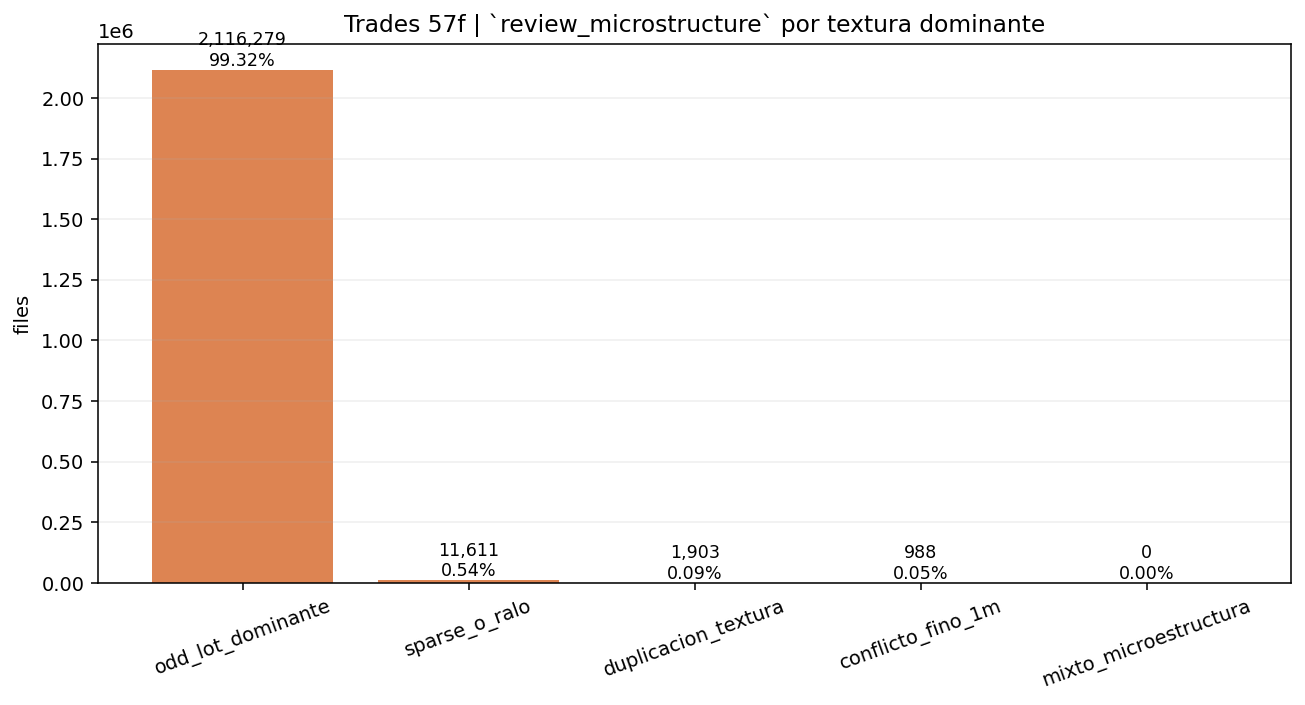

,odd_lot_dominante,duplicacion_textura,conflicto_fino_1m,sparse_o_ralo,mixto_microestructura
0,2116279,1903,988,11611,0


In [14]:
display_trades_universe_section('review_microstructure_texturas')


## `reference_scale_mismatch` por bucket de escala

Responde a:

- que factores de escala dominan el bucket;
- y si estamos ante una sola patologia o una familia amplia de desajustes.


## `reference_scale_mismatch` por bucket de escala

Responde a: cuales son las escalas dominantes del conflicto y si el bucket esta concentrado en unos pocos factores o disperso.

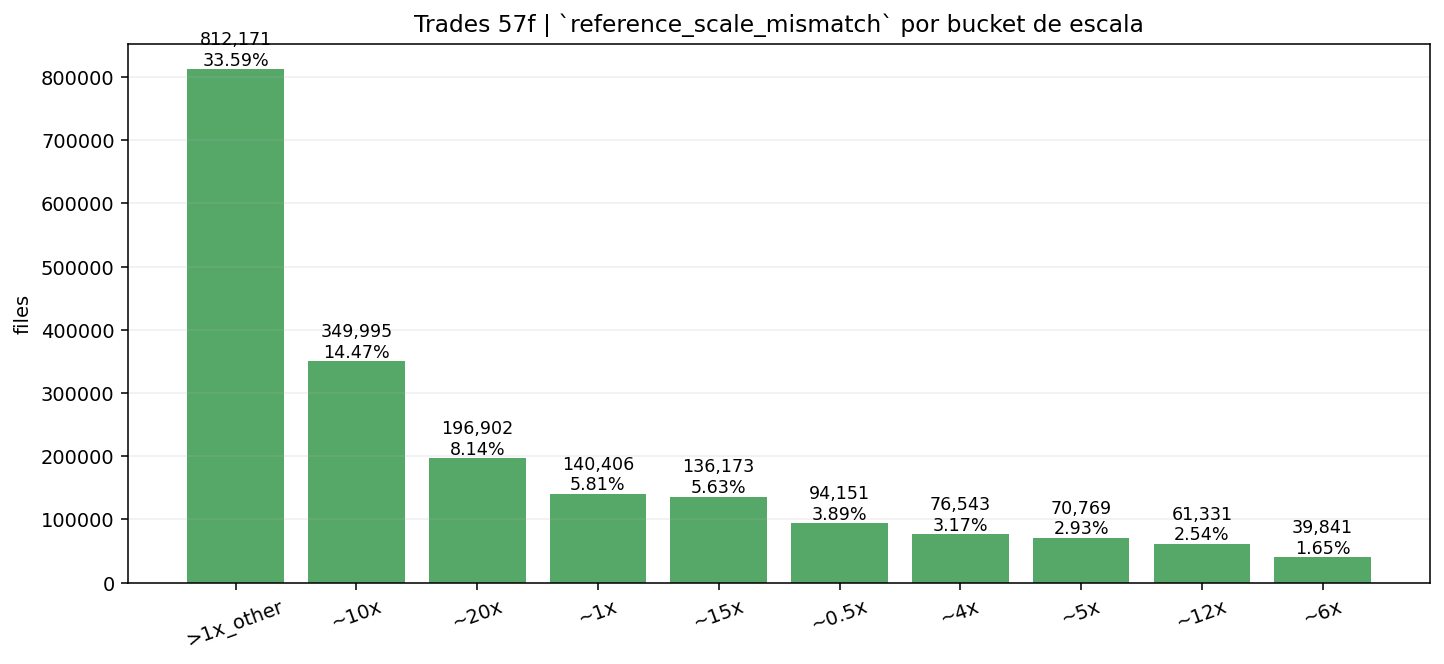

,>1x_other,~10x,near_15x,~20x,~1x,~0.6667x,~1.25x,~5x,~100x,~12x,...,~0.25x,near_0.8x,~0.8x,~5000x,near_5000x,~0.2x,near_0.3333x,near_0.1x,near_0.2x,~0.1x
0,812171,349995,27053,196902,140406,35960,4080,70769,36519,61331,...,14598,20790,11777,7088,97,1590,739,6,6,1


In [15]:
display_trades_universe_section('reference_scale_buckets')


## `review` por severidad interna de rehabilitacion

Responde a:

- cuanto cae ya en rehabilitacion estricta;
- cuanto entra solo en la extendida;
- y cuanto sigue cerca de `1x` pero no pasa todavia los cortes.


## `review` por severidad interna de rehabilitacion

Responde a: que parte de `review` cae en rehabilitacion estricta, que parte solo entra en la extendida y que masa sigue lejos de `~1x`.

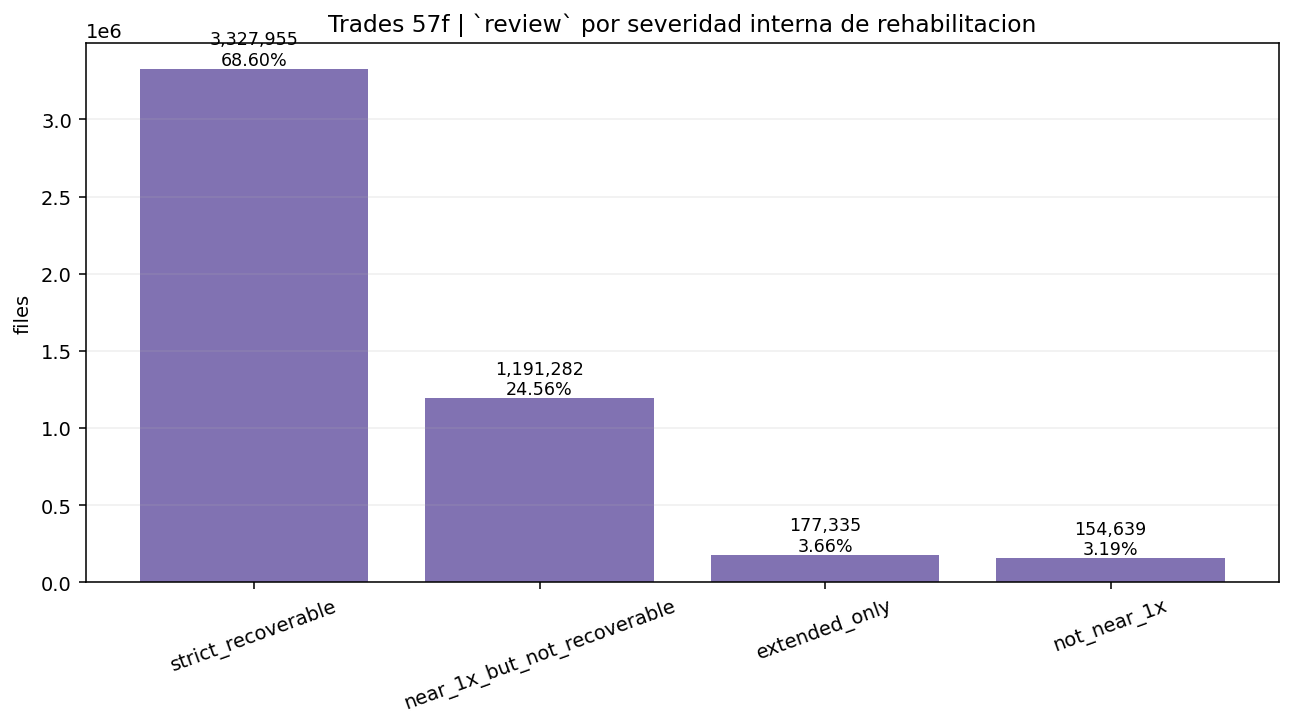

,strict_recoverable,extended_only,near_1x_but_not_recoverable,not_near_1x
0,3327955,177335,1191282,154639


In [16]:
display_trades_universe_section('review_rehab_detalle')


## Recordatorio metodologico final

Este notebook no cierra por si solo la inspeccion de `trades`.

Su funcion es dar:

- mapa global del universo completo;
- granularidad poblacional moderna;
- y soporte visual ejecutable para el inspector.

La lectura file-level sigue viviendo en:

- `trades_inspection_notebook_v0_1.ipynb`
- los casepacks por familia
- y las muestras estratificadas ya promovidas.
